# Loan Approval Prediction

----------------------------------------------------------------------------------------------------------------------------------------------------

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# Dataset

In [2]:
df = pd.read_csv("Loan Dataset.csv")
df

,Applicant_ID,Gender,Age,Marital_Status,Dependents,Education,Employment_Status,Occupation_Type,Residential_Status,City/Town,...,Loan_Amount_Requested,Loan_Term,Loan_Purpose,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
0,1,Female,25,Married,2,Graduate,Employed,Business,Own,Urban,...,24535,209,Home,4.27,Secured,Yes,8,20,0.81,1
1,2,Male,36,Married,2,High School,Employed,Business,Own,Suburban,...,8288,33,Home,14.78,Unsecured,Yes,9,9,0.17,0
2,3,Male,43,Single,0,Postgraduate,Self-Employed,Freelancer,Own,Urban,...,10308,159,Vehicle,12.33,Secured,Yes,7,27,0.25,0
3,4,Female,28,Married,0,High School,Self-Employed,Freelancer,Rent,Suburban,...,33937,39,Personal,8.77,Secured,No,9,16,0.27,1
4,5,Female,32,Single,0,Graduate,Employed,Salaried,Rent,Suburban,...,23360,34,Home,9.04,Unsecured,No,1,17,0.32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,51996,Female,47,Divorced,1,High School,Self-Employed,Professional,Own,Urban,...,15723,60,Home,12.52,Secured,Yes,2,26,0.61,1
51996,51997,Male,25,Married,3,High School,Self-Employed,Freelancer,Rent,Urban,...,21209,237,Vehicle,5.21,Unsecured,No,8,26,0.04,1
51997,51998,Female,48,Married,0,High School,Unemployed,Business,Rent,Urban,...,10540,60,Education,10.60,Unsecured,No,8,24,0.31,0
51998,51999,Female,48,Divorced,1,High School,Employed,Business,Own,Urban,...,16765,32,Vehicle,8.11,Secured,Yes,3,12,0.34,0


# Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Applicant_ID                52000 non-null  int64  
 1   Gender                      52000 non-null  object 
 2   Age                         52000 non-null  int64  
 3   Marital_Status              52000 non-null  object 
 4   Dependents                  52000 non-null  int64  
 5   Education                   52000 non-null  object 
 6   Employment_Status           52000 non-null  object 
 7   Occupation_Type             52000 non-null  object 
 8   Residential_Status          52000 non-null  object 
 9   City/Town                   52000 non-null  object 
 10  Annual_Income               52000 non-null  int64  
 11  Monthly_Expenses            52000 non-null  int64  
 12  Credit_Score                52000 non-null  int64  
 13  Existing_Loans              520

# Numeric Columns

In [4]:
numeric_cols =[features for features in df.columns if df[features].dtypes != 'O']
numeric_cols , len(numeric_cols)

(['Applicant_ID',
  'Age',
  'Dependents',
  'Annual_Income',
  'Monthly_Expenses',
  'Credit_Score',
  'Existing_Loans',
  'Total_Existing_Loan_Amount',
  'Outstanding_Debt',
  'Loan_History',
  'Loan_Amount_Requested',
  'Loan_Term',
  'Interest_Rate',
  'Bank_Account_History',
  'Transaction_Frequency',
  'Default_Risk',
  'Loan_Approval_Status'],
 17)

# Object Columns

In [5]:
object_cols = [features for features in df.columns if df[features].dtype == 'O']
object_cols , len(object_cols)

(['Gender',
  'Marital_Status',
  'Education',
  'Employment_Status',
  'Occupation_Type',
  'Residential_Status',
  'City/Town',
  'Loan_Purpose',
  'Loan_Type',
  'Co-Applicant'],
 10)

# Checking Null Values

In [6]:
df.isnull().sum().sum()
# No Null Values

np.int64(0)

# Checking For Duplicates Values

In [7]:
df.duplicated().sum()
# No Duplicates present

np.int64(0)

# 7-Point Summary for the Numerical Features

In [8]:
df.describe()

,Applicant_ID,Age,Dependents,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,Loan_History,Loan_Amount_Requested,Loan_Term,Interest_Rate,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
count,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000
mean,26000.500000,38.898385,1.498000,83588.474404,2748.064885,678.089019,0.997865,24939.087962,14984.864923,0.198596,21102.765481,125.827019,9.253494,4.503923,17.031808,0.500204,0.641654
std,15011.251336,10.553928,1.118077,35720.851522,1295.678763,159.990367,0.815586,14407.886552,8663.404305,0.398947,8224.940906,65.509959,3.318356,2.872721,7.212011,0.289939,0.479519
min,1.000000,18.000000,0.000000,20009.000000,500.000000,300.000000,0.000000,0.000000,0.000000,0.000000,5000.000000,12.000000,3.500000,0.000000,5.000000,0.000000,0.000000
25%,13000.750000,31.000000,0.000000,55564.000000,1636.000000,553.000000,0.000000,12498.000000,7511.750000,0.000000,16941.750000,69.000000,6.400000,2.000000,11.000000,0.250000,0.000000
50%,26000.500000,38.000000,1.000000,78839.000000,2739.000000,742.000000,1.000000,24964.000000,14984.500000,0.000000,21039.000000,126.000000,9.240000,5.000000,17.000000,0.500000,1.000000
75%,39000.250000,45.000000,2.000000,114226.000000,3866.000000,796.000000,2.000000,37399.500000,22432.250000,0.000000,25809.000000,182.000000,12.140000,7.000000,23.000000,0.750000,1.000000
max,52000.000000,69.000000,3.000000,149998.000000,4999.000000,849.000000,2.000000,49999.000000,29998.000000,1.000000,44848.000000,239.000000,15.000000,9.000000,29.000000,1.000000,1.000000


# Feaatures with Less than 10 categories Value In Numeric Features

In [9]:
multiclass_cols = [features for features in numeric_cols if len(df[features].unique()) <= 10]
multiclass_cols

['Dependents',
 'Existing_Loans',
 'Loan_History',
 'Bank_Account_History',
 'Loan_Approval_Status']

# Unique Values in Multiclass features

In [10]:
for cols in multiclass_cols:
    print(f'{cols} = {df[cols].unique()}')

Dependents = [2 0 1 3]
Existing_Loans = [0 1 2]
Loan_History = [0 1]
Bank_Account_History = [8 9 7 1 4 2 6 3 5 0]
Loan_Approval_Status = [1 0]


# Univariate analysis for numeric features

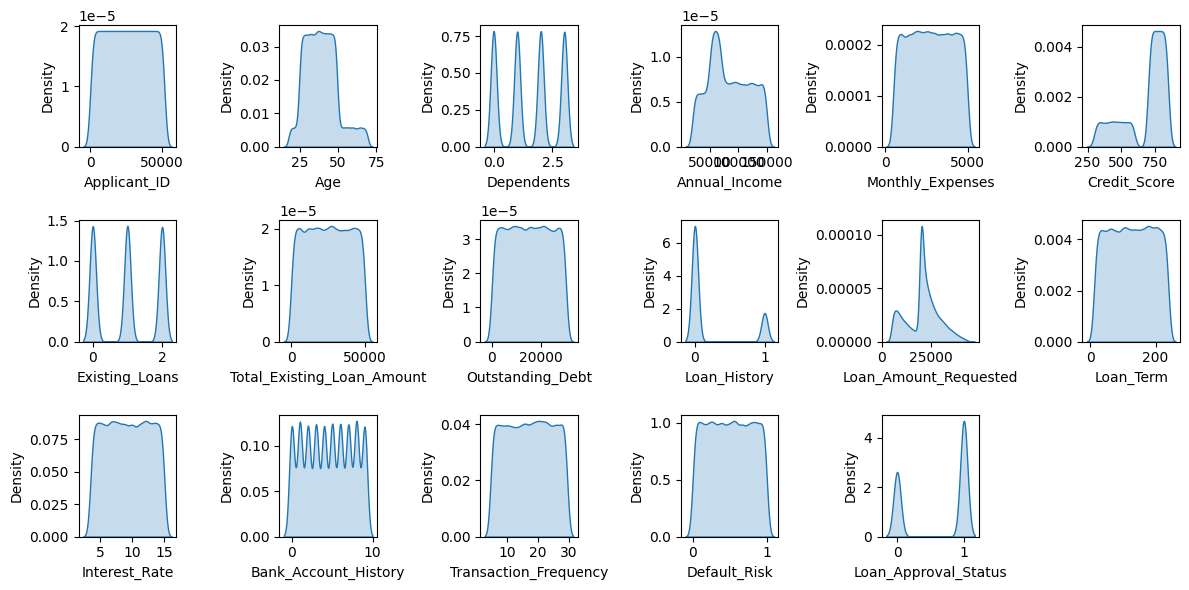

In [11]:
plt.figure(figsize=(12,6))
for i in range(len(numeric_cols)):
    if(i<=17):
        plt.subplot(3,6,i+1)
        sns.kdeplot(df[numeric_cols[i]],shade = True)
        plt.xlabel(numeric_cols[i])
    
plt.tight_layout()
plt.show()

# Box Plot

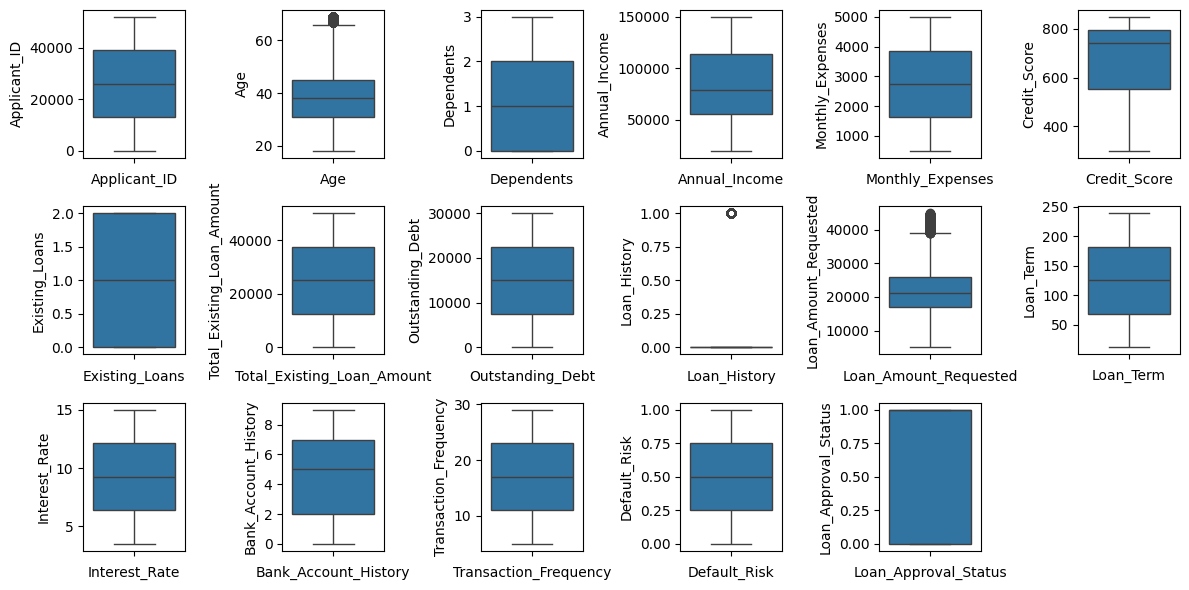

In [12]:
plt.figure(figsize=(12,6))
for i in range(len(numeric_cols)):
    if(i<=17):
        plt.subplot(3,6,i+1)
        sns.boxplot(df[numeric_cols[i]])
        plt.xlabel(numeric_cols[i])
plt.tight_layout()
plt.show()

# Observation
- There are outliers in Loan_Amount_Requested and in Age feature.
- We are going to check wehter the loan_amount_requested contains 0 or not , if not we are going to do log1p transform to remove the effect of outliter
- And the Rest of Features doesnot have much outliers effect

In [13]:
np.any(df['Loan_Amount_Requested'] == 0 ,axis = 0)

np.False_

There is No such value we can go and perform the log transform to the laon_amount_requested feature

# Observation
- As we are perform Decision Trees , the performance is not much affected by the big values 
- Because the splitting is done on the thershold value which will be similar for 500000 or transformed value 8.12 , both has same logic 
- So the log1p transform is not needed for the decision trees .
- It is needed for the distance based algorithm

In [14]:
# df['Loan_Amount_Requested'] = np.log1p(df['Loan_Amount_Requested'])
# df

# Correlation for Numerical values

In [15]:
df[numeric_cols].corr()

,Applicant_ID,Age,Dependents,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,Loan_History,Loan_Amount_Requested,Loan_Term,Interest_Rate,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
Applicant_ID,1.000000,-0.007557,-0.000582,-0.000725,0.000958,-0.003336,-0.002055,-0.001616,0.003637,0.000135,0.002564,-0.002477,0.003025,0.000140,0.001448,-0.006383,-0.001939
Age,-0.007557,1.000000,-0.002626,-0.189818,0.008444,-0.254156,0.002066,-0.006428,-0.003778,-0.001172,-0.204566,-0.001235,0.002544,-0.000789,0.001336,0.000215,-0.183683
Dependents,-0.000582,-0.002626,1.000000,-0.011867,0.002250,-0.007241,0.002579,-0.002585,-0.003333,0.007552,-0.007374,0.001929,-0.000834,-0.009925,0.004403,-0.002113,-0.002736
Annual_Income,-0.000725,-0.189818,-0.011867,1.000000,0.000128,0.651278,-0.002928,0.004676,-0.000681,0.003453,0.849426,0.006622,0.000629,-0.001720,0.001356,-0.002829,0.472145
Monthly_Expenses,0.000958,0.008444,0.002250,0.000128,1.000000,0.001552,0.001054,0.003962,0.006893,-0.000363,0.002997,0.003607,-0.003814,-0.001418,-0.003023,-0.002783,0.003768
Credit_Score,-0.003336,-0.254156,-0.007241,0.651278,0.001552,1.000000,0.002977,0.008320,0.001038,-0.000948,0.703467,0.001501,0.003880,0.000038,0.001121,-0.001962,0.616977
Existing_Loans,-0.002055,0.002066,0.002579,-0.002928,0.001054,0.002977,1.000000,-0.000717,0.004093,0.003963,-0.004288,-0.001301,0.006585,-0.002553,0.004667,-0.001306,0.004535
Total_Existing_Loan_Amount,-0.001616,-0.006428,-0.002585,0.004676,0.003962,0.008320,-0.000717,1.000000,0.008701,0.003496,0.005453,-0.007256,-0.004289,-0.007596,-0.006852,0.000170,0.005588
Outstanding_Debt,0.003637,-0.003778,-0.003333,-0.000681,0.006893,0.001038,0.004093,0.008701,1.000000,-0.003221,0.002093,-0.004636,0.006894,-0.003361,-0.009631,0.013777,-0.002962
Loan_History,0.000135,-0.001172,0.007552,0.003453,-0.000363,-0.000948,0.003963,0.003496,-0.003221,1.000000,0.001528,-0.002014,-0.007862,0.008541,-0.011493,-0.003444,0.001070


# Heatmap for Numerical Features

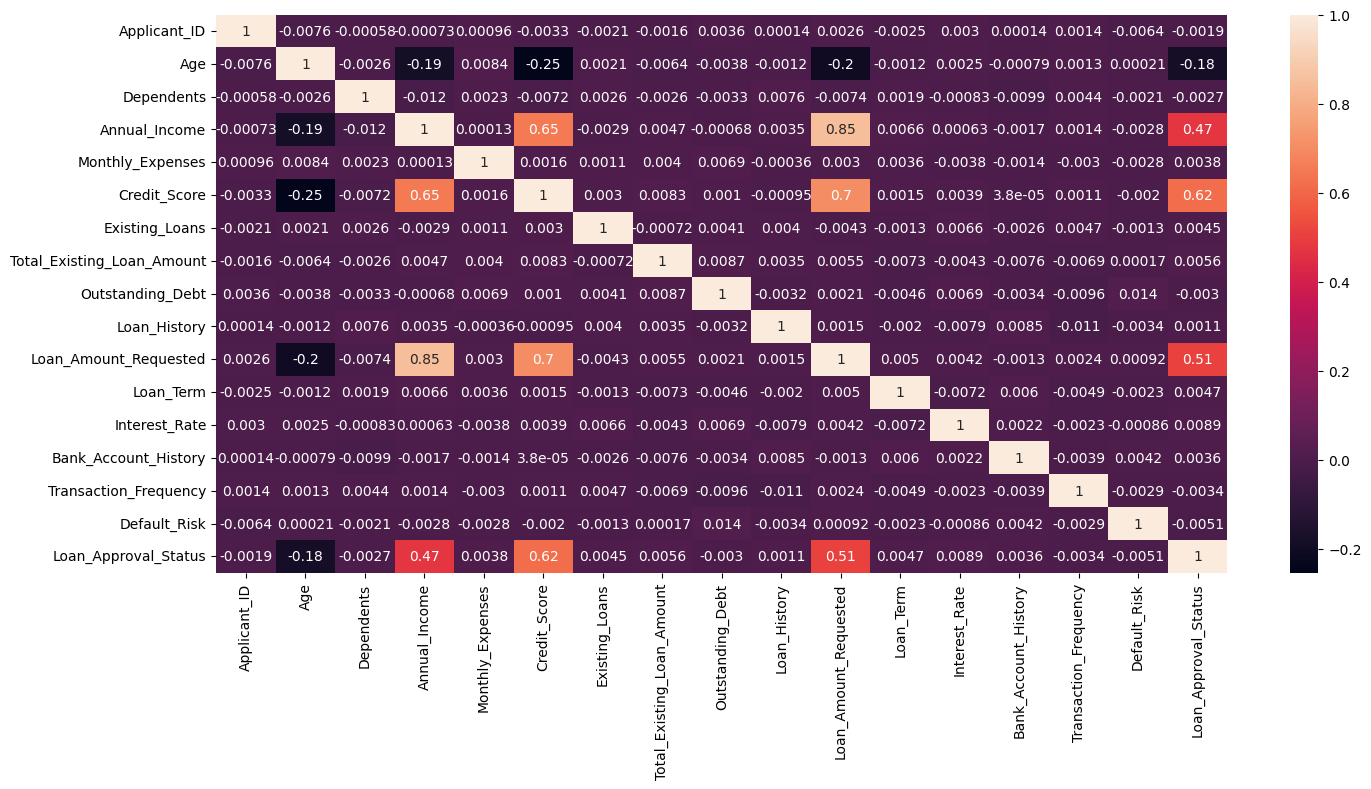

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(df[numeric_cols].corr() ,annot = True)
plt.tight_layout()
plt.show()

# Pairplot

In [17]:
# plt.figure(figsize=(12,8))
# sns.pairplot(df)
# plt.show()

# Observation
- Mostly the data is uniformly distributed 
- Not much error

# Object Columns and there Categoies

In [18]:
for cols in object_cols:
    print(f'{cols}={df[cols].unique()}')

Gender=['Female' 'Male']
Marital_Status=['Married' 'Single' 'Divorced']
Education=['Graduate' 'High School' 'Postgraduate']
Employment_Status=['Employed' 'Self-Employed' 'Unemployed']
Occupation_Type=['Business' 'Freelancer' 'Salaried' 'Professional']
Residential_Status=['Own' 'Rent' 'Other']
City/Town=['Urban' 'Suburban' 'Rural']
Loan_Purpose=['Home' 'Vehicle' 'Personal' 'Education']
Loan_Type=['Secured' 'Unsecured']
Co-Applicant=['Yes' 'No']


# Observation
- Doing Label Encoding for the features which are having only 2 categories

# Binary Features

In [19]:
binary_features = [features for features in object_cols if len(df[features].unique())<=2]
binary_features

['Gender', 'Loan_Type', 'Co-Applicant']

# Label Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

for cols in binary_features:
    encoder = LabelEncoder()
    df[cols] = encoder.fit_transform(df[cols])
    
df

,Applicant_ID,Gender,Age,Marital_Status,Dependents,Education,Employment_Status,Occupation_Type,Residential_Status,City/Town,...,Loan_Amount_Requested,Loan_Term,Loan_Purpose,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
0,1,0,25,Married,2,Graduate,Employed,Business,Own,Urban,...,24535,209,Home,4.27,0,1,8,20,0.81,1
1,2,1,36,Married,2,High School,Employed,Business,Own,Suburban,...,8288,33,Home,14.78,1,1,9,9,0.17,0
2,3,1,43,Single,0,Postgraduate,Self-Employed,Freelancer,Own,Urban,...,10308,159,Vehicle,12.33,0,1,7,27,0.25,0
3,4,0,28,Married,0,High School,Self-Employed,Freelancer,Rent,Suburban,...,33937,39,Personal,8.77,0,0,9,16,0.27,1
4,5,0,32,Single,0,Graduate,Employed,Salaried,Rent,Suburban,...,23360,34,Home,9.04,1,0,1,17,0.32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,51996,0,47,Divorced,1,High School,Self-Employed,Professional,Own,Urban,...,15723,60,Home,12.52,0,1,2,26,0.61,1
51996,51997,1,25,Married,3,High School,Self-Employed,Freelancer,Rent,Urban,...,21209,237,Vehicle,5.21,1,0,8,26,0.04,1
51997,51998,0,48,Married,0,High School,Unemployed,Business,Rent,Urban,...,10540,60,Education,10.60,1,0,8,24,0.31,0
51998,51999,0,48,Divorced,1,High School,Employed,Business,Own,Urban,...,16765,32,Vehicle,8.11,0,1,3,12,0.34,0


# Encodings

In [21]:
for cols in binary_features:
    print(f'{cols} = {df[cols].unique()}')

Gender = [0 1]
Loan_Type = [0 1]
Co-Applicant = [1 0]


# Ordinal Encoding
- For Education Feature

In [22]:
from sklearn.preprocessing import OrdinalEncoder

# print(df['Education'].unique())
ordinal_encoder = OrdinalEncoder(categories=[['High School','Graduate','Postgraduate']])
df['Education'] = ordinal_encoder.fit_transform(df[['Education']])
print(df['Education'].unique())

[1. 0. 2.]


# Observation
- The rest of the features have multiple categories and are not any interniscally related , so we will do OHE


# One Hot Encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder

mulitple_cat_cols = [features for features in object_cols if len(df[features].unique())>2]

for cols in mulitple_cat_cols:
    if(cols != 'Education'):
        ohe = OneHotEncoder(sparse_output=False , drop = 'first')
        encoded_values = ohe.fit_transform(df[[cols]])
        encoded_df = pd.DataFrame(encoded_values , columns = ohe.get_feature_names_out() , index = df.index)
        df = pd.concat([df,encoded_df.astype(int)],axis = 1)
        df.drop(cols , axis = 1 , inplace = True)
df

,Applicant_ID,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,...,Occupation_Type_Freelancer,Occupation_Type_Professional,Occupation_Type_Salaried,Residential_Status_Own,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle
0,1,0,25,2,1.0,139901,2533,743,0,10942,...,0,0,0,1,0,0,1,1,0,0
1,2,1,36,2,0.0,21162,4041,468,1,48731,...,0,0,0,1,0,1,0,1,0,0
2,3,1,43,0,2.0,27815,3453,389,2,6925,...,1,0,0,1,0,0,1,0,0,1
3,4,0,28,0,0.0,137853,2732,778,0,42016,...,1,0,0,0,1,1,0,0,1,0
4,5,0,32,0,1.0,81753,1648,752,2,31747,...,0,0,1,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,51996,0,47,1,0.0,56085,1794,381,0,3338,...,0,1,0,1,0,0,1,1,0,0
51996,51997,1,25,3,0.0,79062,1371,726,1,23659,...,1,0,0,0,1,0,1,0,0,1
51997,51998,0,48,0,0.0,57471,3442,396,2,4389,...,0,0,0,0,1,0,1,0,0,0
51998,51999,0,48,1,0.0,49495,2874,362,0,25518,...,0,0,0,1,0,0,1,0,0,1


# Observation
- The drop = 'first'--> parameter is used to drop first category alphabetically and rest of the columns are used to determine the category  
    Example - rural suburban urban is encoded as 1 , 0 , 0    or   0 , 1 ,0    or   0 , 0 , 1 , but when we do drop = 'first' suppose the rural column is dropped in encoding and the encoded values becomes 0 , 0   or   1 , 0   or    0 , 1 , which is interpreted as when both suburban and urban encoded values are zero then the output was of rural category.

- index = df.index --> is used to allign the concatenated df with proper df's index
- sparse_output = False --> is used to return numpy_darray instead of a sparse matrix

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     52000 non-null  int64  
 1   Gender                           52000 non-null  int64  
 2   Age                              52000 non-null  int64  
 3   Dependents                       52000 non-null  int64  
 4   Education                        52000 non-null  float64
 5   Annual_Income                    52000 non-null  int64  
 6   Monthly_Expenses                 52000 non-null  int64  
 7   Credit_Score                     52000 non-null  int64  
 8   Existing_Loans                   52000 non-null  int64  
 9   Total_Existing_Loan_Amount       52000 non-null  int64  
 10  Outstanding_Debt                 52000 non-null  int64  
 11  Loan_History                     52000 non-null  int64  
 12  Loan_Amount_Reques

# Changing type to Int

In [25]:
df['Education'] = df['Education'].astype(int)
df['Education']

0        1
1        0
2        2
3        0
4        1
        ..
51995    0
51996    0
51997    0
51998    0
51999    0
Name: Education, Length: 52000, dtype: int64

# Converted DF Information

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     52000 non-null  int64  
 1   Gender                           52000 non-null  int64  
 2   Age                              52000 non-null  int64  
 3   Dependents                       52000 non-null  int64  
 4   Education                        52000 non-null  int64  
 5   Annual_Income                    52000 non-null  int64  
 6   Monthly_Expenses                 52000 non-null  int64  
 7   Credit_Score                     52000 non-null  int64  
 8   Existing_Loans                   52000 non-null  int64  
 9   Total_Existing_Loan_Amount       52000 non-null  int64  
 10  Outstanding_Debt                 52000 non-null  int64  
 11  Loan_History                     52000 non-null  int64  
 12  Loan_Amount_Reques

In [27]:
df['loan_income_ratio'] = df['Loan_Amount_Requested'] / df['Annual_Income'] 
df['loan_income_ratio']

0        0.175374
1        0.391645
2        0.370591
3        0.246183
4        0.285739
           ...   
51995    0.280342
51996    0.268258
51997    0.183397
51998    0.338721
51999    0.226334
Name: loan_income_ratio, Length: 52000, dtype: float64

In [28]:
df['Monthly_Income'] = df['Annual_Income'] / 12
df['Monthly_Income']

0        11658.416667
1         1763.500000
2         2317.916667
3        11487.750000
4         6812.750000
             ...     
51995     4673.750000
51996     6588.500000
51997     4789.250000
51998     4124.583333
51999     7530.916667
Name: Monthly_Income, Length: 52000, dtype: float64

In [29]:
df['Debt_to_income_ratio'] = df['Outstanding_Debt'] / df['Annual_Income']
df['Debt_to_income_ratio']

0        0.141686
1        0.865750
2        0.497969
3        0.207525
4        0.107397
           ...   
51995    0.212338
51996    0.312362
51997    0.215187
51998    0.267502
51999    0.121820
Name: Debt_to_income_ratio, Length: 52000, dtype: float64

In [30]:
df['Loan_X_Term'] = df['Loan_Amount_Requested'] * df['Loan_Term']
df['Loan_X_Term']

0        5127815
1         273504
2        1638972
3        1323543
4         794240
          ...   
51995     943380
51996    5026533
51997     632400
51998     536480
51999    1902222
Name: Loan_X_Term, Length: 52000, dtype: int64

# Correlation

In [31]:
df.corr()

,Applicant_ID,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,...,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle,loan_income_ratio,Monthly_Income,Debt_to_income_ratio,Loan_X_Term
Applicant_ID,1.000000,0.008922,-0.007557,-0.000582,-0.000657,-0.000725,0.000958,-0.003336,-0.002055,-0.001616,...,-0.002363,-0.000060,-0.001155,-0.003632,-0.003088,0.002625,0.002624,-0.000725,0.003851,0.000280
Gender,0.008922,1.000000,-0.000867,0.001497,0.000189,-0.008029,-0.000850,-0.005020,-0.000588,-0.005555,...,-0.003047,0.000604,0.003878,0.003300,0.003157,0.002148,0.000666,-0.008029,0.006205,-0.004557
Age,-0.007557,-0.000867,1.000000,-0.002626,0.006146,-0.189818,0.008444,-0.254156,0.002066,-0.006428,...,0.005170,-0.000155,0.000867,0.001675,-0.005932,0.005386,0.001081,-0.189818,0.130330,-0.116533
Dependents,-0.000582,0.001497,-0.002626,1.000000,0.004498,-0.011867,0.002250,-0.007241,0.002579,-0.002585,...,-0.000256,0.006369,-0.007008,-0.002654,0.007262,-0.000206,0.007209,-0.011867,0.004754,-0.003965
Education,-0.000657,0.000189,0.006146,0.004498,1.000000,-0.002928,-0.002715,-0.000756,0.002581,0.005899,...,0.000175,-0.000903,0.000661,-0.000857,0.006748,-0.007429,0.002012,-0.002928,0.001733,-0.004142
Annual_Income,-0.000725,-0.008029,-0.189818,-0.011867,-0.002928,1.000000,0.000128,0.651278,-0.002928,0.004676,...,-0.004923,0.005012,-0.004953,0.002992,0.003980,-0.005785,-0.396550,1.000000,-0.562788,0.489101
Monthly_Expenses,0.000958,-0.000850,0.008444,0.002250,-0.002715,0.000128,1.000000,0.001552,0.001054,0.003962,...,-0.001928,-0.006388,0.001600,-0.001258,-0.000291,-0.002679,0.002050,0.000128,0.002186,0.003668
Credit_Score,-0.003336,-0.005020,-0.254156,-0.007241,-0.000756,0.651278,0.001552,1.000000,0.002977,0.008320,...,-0.007222,0.003927,-0.003682,-0.000846,0.010931,-0.000343,0.004670,0.651278,-0.444928,0.402098
Existing_Loans,-0.002055,-0.000588,0.002066,0.002579,0.002581,-0.002928,0.001054,0.002977,1.000000,-0.000717,...,-0.000037,0.002691,-0.004111,0.001089,-0.001348,0.001305,-0.000151,-0.002928,0.005408,-0.002305
Total_Existing_Loan_Amount,-0.001616,-0.005555,-0.006428,-0.002585,0.005899,0.004676,0.003962,0.008320,-0.000717,1.000000,...,-0.007768,0.002203,-0.006018,0.004938,0.000693,-0.003294,-0.001158,0.004676,0.000841,-0.002904


# Heat Map

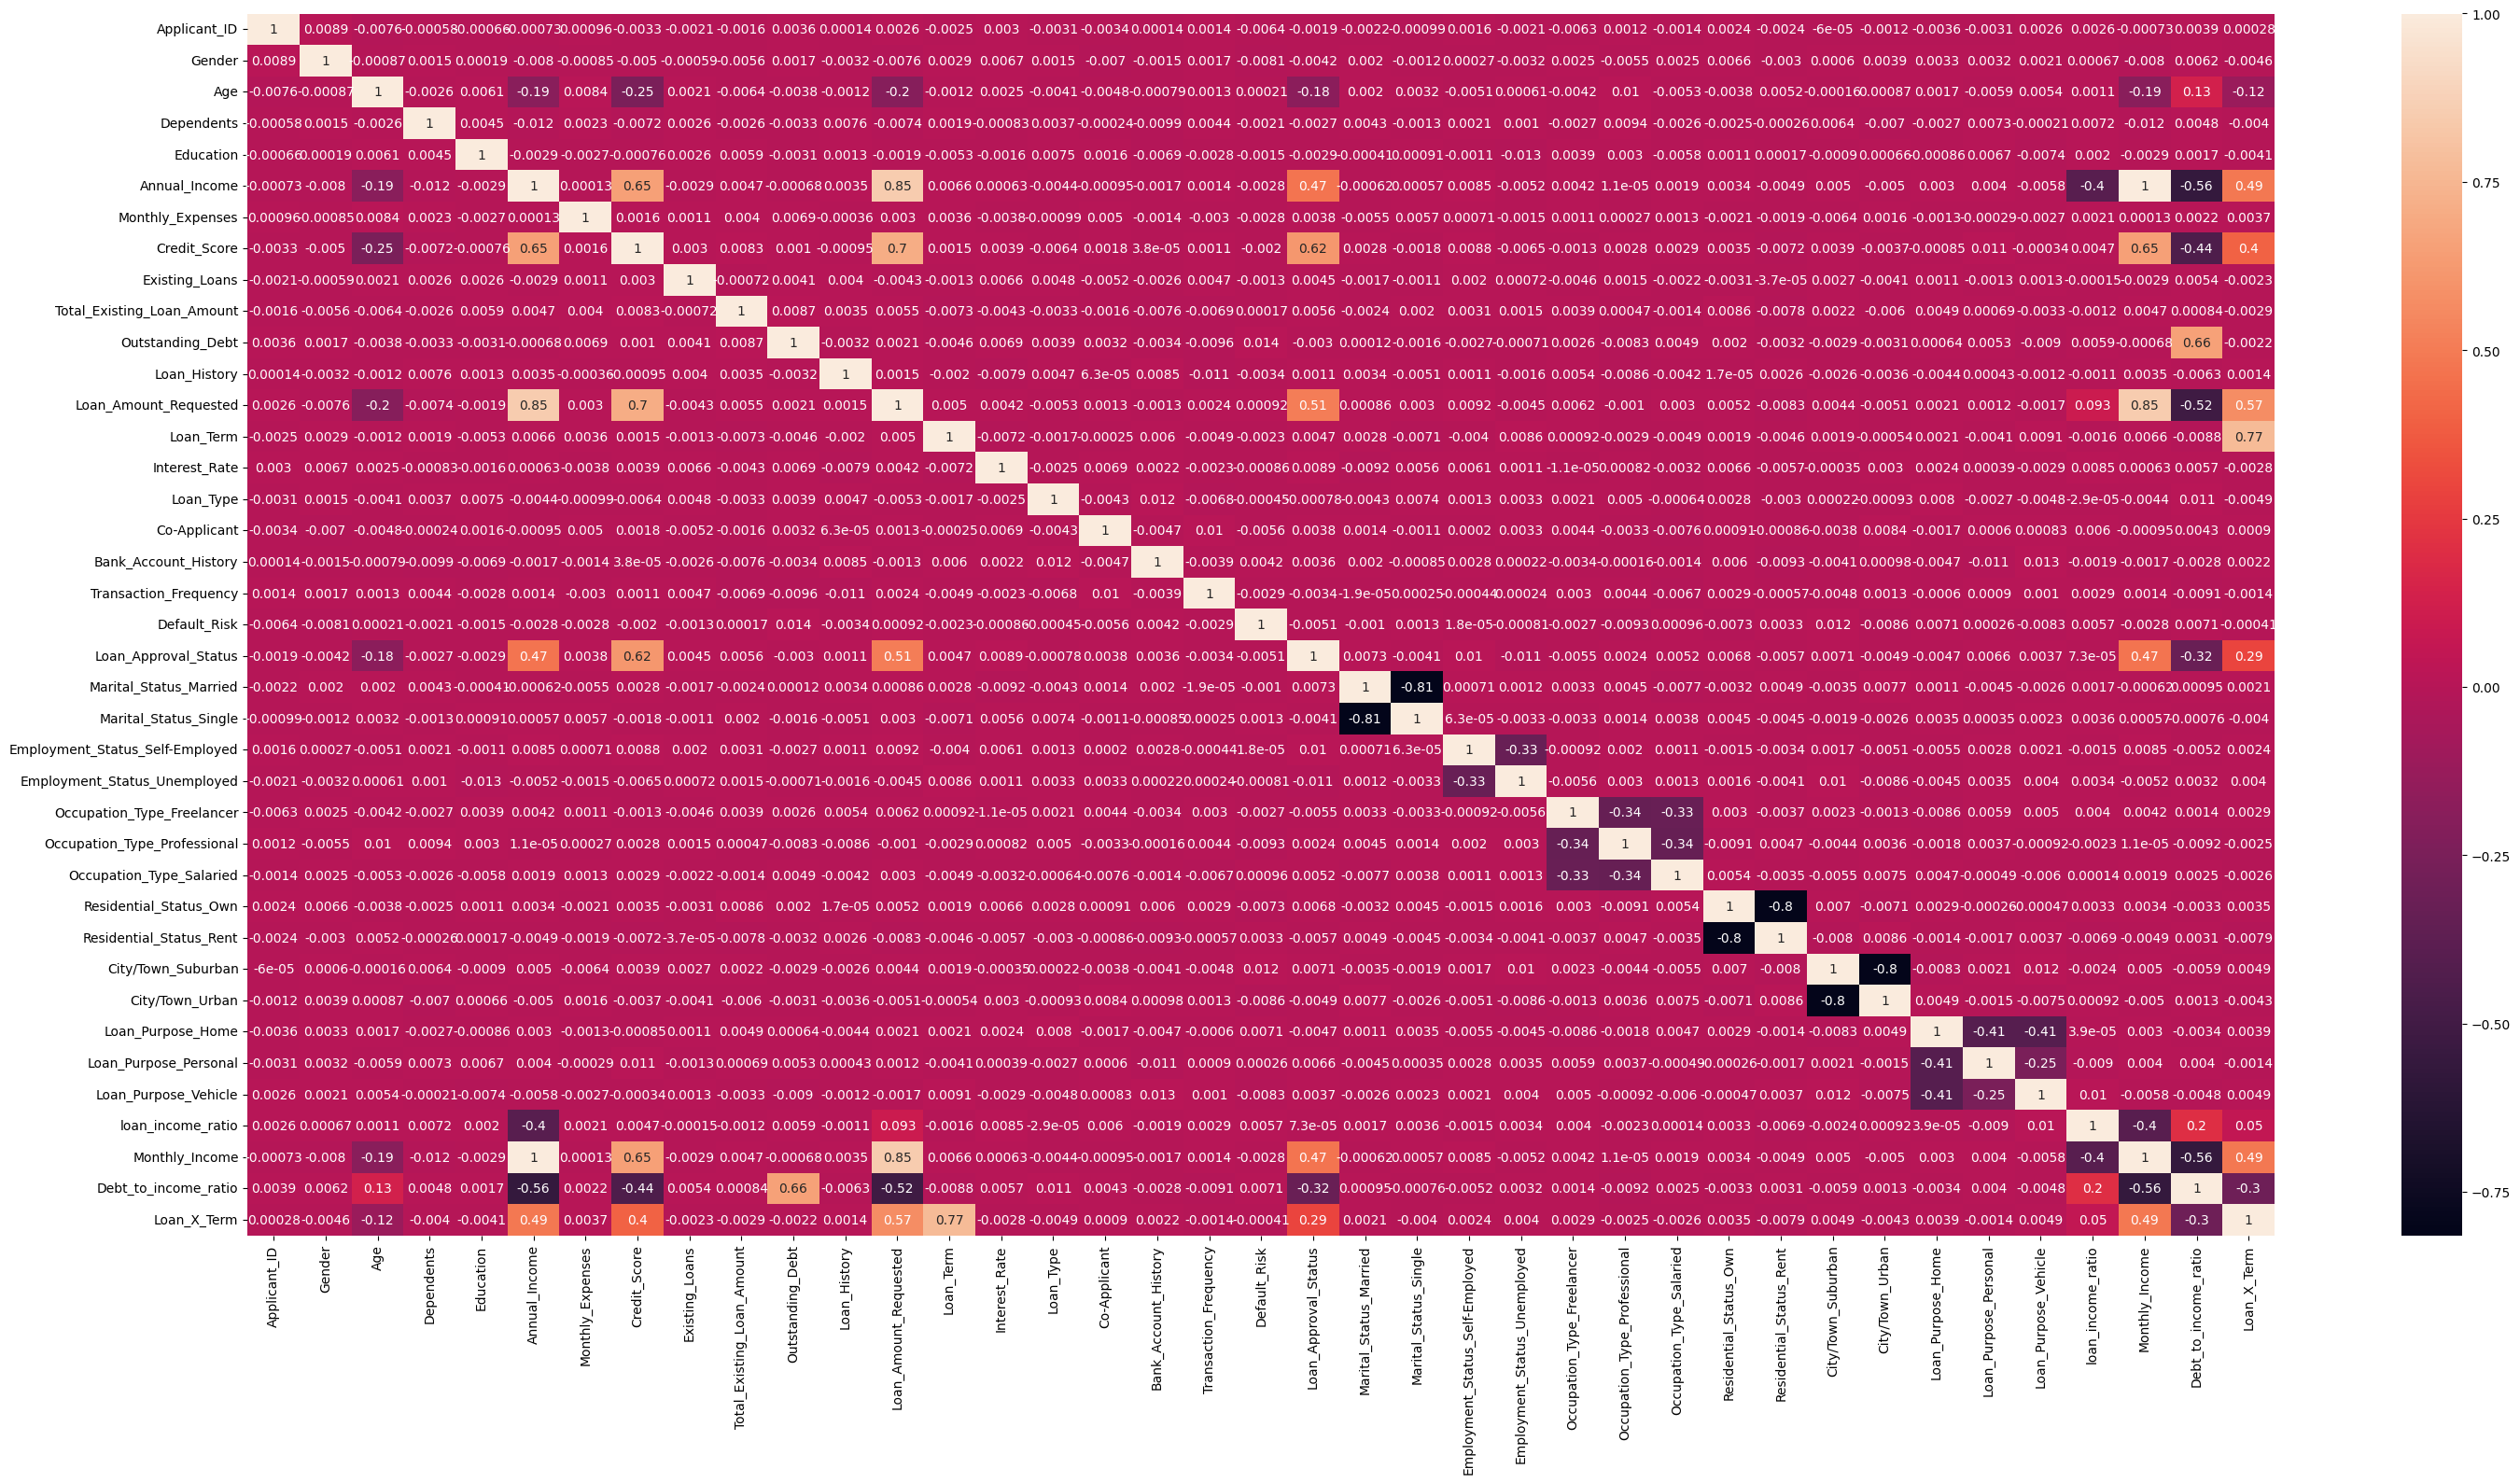

In [32]:
plt.figure(figsize=(30,16))
sns.heatmap(df.corr() ,annot = True)
plt.tight_layout()
plt.show()


# Description

In [33]:
df.describe()

,Applicant_ID,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,...,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle,loan_income_ratio,Monthly_Income,Debt_to_income_ratio,Loan_X_Term
count,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,...,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,5.200000e+04
mean,26000.500000,0.500212,38.898385,1.498000,0.801442,83588.474404,2748.064885,678.089019,0.997865,24939.087962,...,0.299769,0.300135,0.599769,0.402288,0.199615,0.199173,0.263236,6965.706200,0.227311,2.657966e+06
std,15011.251336,0.500005,10.553928,1.118077,0.748890,35720.851522,1295.678763,159.990367,0.815586,14407.886552,...,0.458161,0.458321,0.489950,0.490364,0.399715,0.399382,0.063589,2976.737627,0.199757,1.809096e+06
min,1.000000,0.000000,18.000000,0.000000,0.000000,20009.000000,500.000000,300.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.073694,1667.416667,0.000000,6.326400e+04
25%,13000.750000,0.000000,31.000000,0.000000,0.000000,55564.000000,1636.000000,553.000000,0.000000,12498.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220359,4630.333333,0.088783,1.150054e+06
50%,26000.500000,1.000000,38.000000,1.000000,1.000000,78839.000000,2739.000000,742.000000,1.000000,24964.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.267173,6569.916667,0.179896,2.320000e+06
75%,39000.250000,1.000000,45.000000,2.000000,1.000000,114226.000000,3866.000000,796.000000,2.000000,37399.500000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.298301,9518.833333,0.301678,3.914457e+06
max,52000.000000,1.000000,69.000000,3.000000,2.000000,149998.000000,4999.000000,849.000000,2.000000,49999.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.400000,12499.833333,1.481750,1.051414e+07


# The Cleaned and Featured Dataset
- We are going to drop the applicant ID because it is not going to help in prediction

In [34]:
df.drop('Applicant_ID',axis = 1 , inplace =True)
df

,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,...,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle,loan_income_ratio,Monthly_Income,Debt_to_income_ratio,Loan_X_Term
0,0,25,2,1,139901,2533,743,0,10942,19822,...,0,0,1,1,0,0,0.175374,11658.416667,0.141686,5127815
1,1,36,2,0,21162,4041,468,1,48731,18321,...,0,1,0,1,0,0,0.391645,1763.500000,0.865750,273504
2,1,43,0,2,27815,3453,389,2,6925,13851,...,0,0,1,0,0,1,0.370591,2317.916667,0.497969,1638972
3,0,28,0,0,137853,2732,778,0,42016,28608,...,1,1,0,0,1,0,0.246183,11487.750000,0.207525,1323543
4,0,32,0,1,81753,1648,752,2,31747,8780,...,1,1,0,1,0,0,0.285739,6812.750000,0.107397,794240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,0,47,1,0,56085,1794,381,0,3338,11909,...,0,0,1,1,0,0,0.280342,4673.750000,0.212338,943380
51996,1,25,3,0,79062,1371,726,1,23659,24696,...,1,0,1,0,0,1,0.268258,6588.500000,0.312362,5026533
51997,0,48,0,0,57471,3442,396,2,4389,12367,...,1,0,1,0,0,0,0.183397,4789.250000,0.215187,632400
51998,0,48,1,0,49495,2874,362,0,25518,13240,...,0,0,1,0,0,1,0.338721,4124.583333,0.267502,536480


# Dependent and Independent Features

In [35]:
df.columns

Index(['Gender', 'Age', 'Dependents', 'Education', 'Annual_Income',
       'Monthly_Expenses', 'Credit_Score', 'Existing_Loans',
       'Total_Existing_Loan_Amount', 'Outstanding_Debt', 'Loan_History',
       'Loan_Amount_Requested', 'Loan_Term', 'Interest_Rate', 'Loan_Type',
       'Co-Applicant', 'Bank_Account_History', 'Transaction_Frequency',
       'Default_Risk', 'Loan_Approval_Status', 'Marital_Status_Married',
       'Marital_Status_Single', 'Employment_Status_Self-Employed',
       'Employment_Status_Unemployed', 'Occupation_Type_Freelancer',
       'Occupation_Type_Professional', 'Occupation_Type_Salaried',
       'Residential_Status_Own', 'Residential_Status_Rent',
       'City/Town_Suburban', 'City/Town_Urban', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Loan_Purpose_Vehicle', 'loan_income_ratio',
       'Monthly_Income', 'Debt_to_income_ratio', 'Loan_X_Term'],
      dtype='object')

In [36]:
X = df[['Gender', 'Age', 'Dependents', 'Education', 'Annual_Income','Monthly_Expenses', 'Credit_Score', 'Existing_Loans','Total_Existing_Loan_Amount', 'Outstanding_Debt', 'Loan_History',
       'Loan_Amount_Requested', 'Loan_Term', 'Interest_Rate', 'Loan_Type',
       'Co-Applicant', 'Bank_Account_History', 'Transaction_Frequency',
       'Default_Risk','Marital_Status_Married',
       'Marital_Status_Single', 'Employment_Status_Self-Employed',
       'Employment_Status_Unemployed', 'Occupation_Type_Freelancer',
       'Occupation_Type_Professional', 'Occupation_Type_Salaried',
       'Residential_Status_Own', 'Residential_Status_Rent',
       'City/Town_Suburban', 'City/Town_Urban', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Loan_Purpose_Vehicle' , 'Loan_X_Term' , 'Debt_to_income_ratio','Monthly_Income','loan_income_ratio']]
Y = df['Loan_Approval_Status']
X

,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,...,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle,Loan_X_Term,Debt_to_income_ratio,Monthly_Income,loan_income_ratio
0,0,25,2,1,139901,2533,743,0,10942,19822,...,0,0,1,1,0,0,5127815,0.141686,11658.416667,0.175374
1,1,36,2,0,21162,4041,468,1,48731,18321,...,0,1,0,1,0,0,273504,0.865750,1763.500000,0.391645
2,1,43,0,2,27815,3453,389,2,6925,13851,...,0,0,1,0,0,1,1638972,0.497969,2317.916667,0.370591
3,0,28,0,0,137853,2732,778,0,42016,28608,...,1,1,0,0,1,0,1323543,0.207525,11487.750000,0.246183
4,0,32,0,1,81753,1648,752,2,31747,8780,...,1,1,0,1,0,0,794240,0.107397,6812.750000,0.285739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,0,47,1,0,56085,1794,381,0,3338,11909,...,0,0,1,1,0,0,943380,0.212338,4673.750000,0.280342
51996,1,25,3,0,79062,1371,726,1,23659,24696,...,1,0,1,0,0,1,5026533,0.312362,6588.500000,0.268258
51997,0,48,0,0,57471,3442,396,2,4389,12367,...,1,0,1,0,0,0,632400,0.215187,4789.250000,0.183397
51998,0,48,1,0,49495,2874,362,0,25518,13240,...,0,0,1,0,0,1,536480,0.267502,4124.583333,0.338721


In [37]:
Y

0        1
1        0
2        0
3        1
4        1
        ..
51995    1
51996    1
51997    0
51998    0
51999    1
Name: Loan_Approval_Status, Length: 52000, dtype: int64

# Train Test Split

In [38]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.25 , random_state=10 ,stratify=Y)

# Observation
- As we are performing Decision Trees we don't require to standardize the input because it works on thershold checking rule based algorithm.

# Model Training

In [39]:
from sklearn.tree import DecisionTreeClassifier

# By default Parameters firstly
classifier = DecisionTreeClassifier()
classifier.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Plotting the tree

In [40]:
# from sklearn import tree
# plt.figure(figsize=(30,30))
# tree.plot_tree(classifier , filled=True)

# Predictions on test Data

In [41]:
Y_pred_test = classifier.predict(X_test)
Y_pred_test

array([1, 1, 1, ..., 0, 0, 1], shape=(13000,))

# Prediction on train data

In [42]:
Y_pred_train = classifier.predict(X_train)
Y_pred_train

array([0, 1, 1, ..., 1, 0, 1], shape=(39000,))

# Perfomance Matrix on Train Data

In [43]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

print(accuracy_score(Y_train , Y_pred_train))
print(confusion_matrix(Y_train , Y_pred_train))
print(classification_report(Y_train , Y_pred_train))

1.0
[[13976     0]
 [    0 25024]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13976
           1       1.00      1.00      1.00     25024

    accuracy                           1.00     39000
   macro avg       1.00      1.00      1.00     39000
weighted avg       1.00      1.00      1.00     39000



# Performance Matrix on Test Data

In [44]:
print(accuracy_score(Y_test , Y_pred_test))
print(confusion_matrix(Y_test , Y_pred_test))
print(classification_report(Y_test , Y_pred_test))

0.7272307692307692
[[2984 1674]
 [1872 6470]]
              precision    recall  f1-score   support

           0       0.61      0.64      0.63      4658
           1       0.79      0.78      0.78      8342

    accuracy                           0.73     13000
   macro avg       0.70      0.71      0.71     13000
weighted avg       0.73      0.73      0.73     13000



# Observation
- From here we can clearly see the model is overfitted because it is giving very good training accuracy and not good test accuracy

# Confusion Matrix

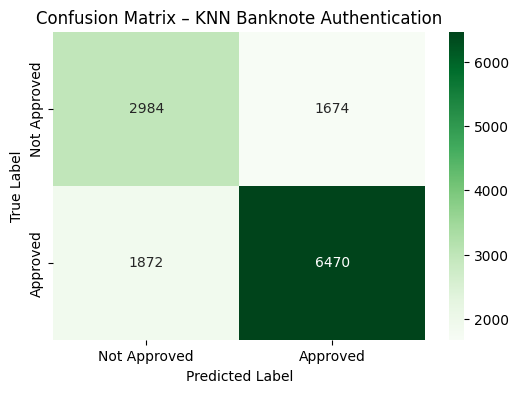

In [45]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test , Y_pred_test), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – KNN Banknote Authentication')
plt.show()


# Parameters

In [46]:
DecisionTreeClassifier()

criterion = ['gini','entropy','log_loss']
splitter = ['best','random']
max_depth = [3,5,10,15,20,None]
max_features = ['auto','sqrt','log2']
min_sample_leaf = [20,50,80,100]
min_samples_split = [50, 100, 200]

param = dict(criterion = criterion , splitter = splitter , max_depth = max_depth , max_features = max_features , min_samples_leaf = min_sample_leaf , min_samples_split = min_samples_split)
param

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [3, 5, 10, 15, 20, None],
 'max_features': ['auto', 'sqrt', 'log2'],
 'min_samples_leaf': [20, 50, 80, 100],
 'min_samples_split': [50, 100, 200]}

# Grid Search Cv

In [47]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=classifier , param_grid=param , cv = 5 , scoring = 'accuracy' , n_jobs = -1)
grid.fit(X_train , Y_train)
print("The Best CV score =",grid.best_score_)
print(grid.best_params_)

The Best CV score = 0.8495641025641026
{'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'min_samples_split': 100, 'splitter': 'best'}


# Prediction Using grid model

In [48]:
Y_pred_grid_test = grid.predict(X_test)
Y_pred_grid_test

array([0, 1, 1, ..., 0, 0, 1], shape=(13000,))

# Performance of Grid Model

In [49]:
print(accuracy_score(Y_test , Y_pred_grid_test))
print(confusion_matrix(Y_test , Y_pred_grid_test))
print(classification_report(Y_test , Y_pred_grid_test))

0.851
[[3290 1368]
 [ 569 7773]]
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      4658
           1       0.85      0.93      0.89      8342

    accuracy                           0.85     13000
   macro avg       0.85      0.82      0.83     13000
weighted avg       0.85      0.85      0.85     13000



# Grid Model's Confusion Matrix

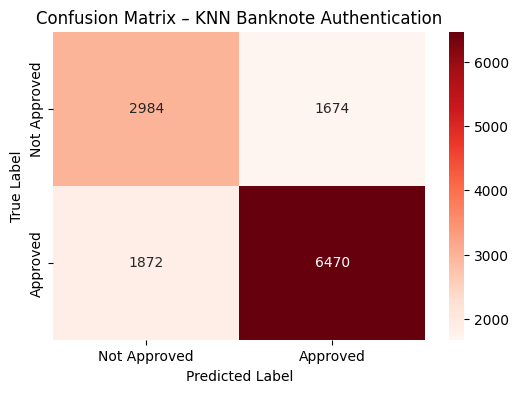

In [50]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test , Y_pred_test), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – KNN Banknote Authentication')
plt.show()

# Prediction of grid model on training data

In [51]:
Y_pred_grid_train = grid.predict(X_train)
Y_pred_grid_train

array([1, 1, 1, ..., 1, 0, 1], shape=(39000,))

# Performance Matrix of Grid Model on Training Data

In [52]:
print(accuracy_score(Y_train , Y_pred_grid_train))
print(confusion_matrix(Y_train , Y_pred_grid_train))
print(classification_report(Y_train , Y_pred_grid_train))

0.8496666666666667
[[ 9861  4115]
 [ 1748 23276]]
              precision    recall  f1-score   support

           0       0.85      0.71      0.77     13976
           1       0.85      0.93      0.89     25024

    accuracy                           0.85     39000
   macro avg       0.85      0.82      0.83     39000
weighted avg       0.85      0.85      0.85     39000



# Dumping the Model

In [53]:
import pickle
pickle.dump(grid,open('loan_approval_model.pkl','wb'))

# Description of X_train

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.describe()

,Gender,Age,Dependents,Education,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,Loan_History,Loan_Amount_Requested,Loan_Term,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status,Marital_Status_Married,Marital_Status_Single,Employment_Status_Self-Employed,Employment_Status_Unemployed,Occupation_Type_Freelancer,Occupation_Type_Professional,Occupation_Type_Salaried,Residential_Status_Own,Residential_Status_Rent,City/Town_Suburban,City/Town_Urban,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_Vehicle,loan_income_ratio,Monthly_Income,Debt_to_income_ratio,Loan_X_Term
count,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,5.200000e+04
mean,0.500212,38.898385,1.498000,0.801442,83588.474404,2748.064885,678.089019,0.997865,24939.087962,14984.864923,0.198596,21102.765481,125.827019,9.253494,0.498135,0.499308,4.503923,17.031808,0.500204,0.641654,0.499173,0.399750,0.302942,0.199538,0.249000,0.253673,0.250135,0.599577,0.299769,0.300135,0.599769,0.402288,0.199615,0.199173,0.263236,6965.706200,0.227311,2.657966e+06
std,0.500005,10.553928,1.118077,0.748890,35720.851522,1295.678763,159.990367,0.815586,14407.886552,8663.404305,0.398947,8224.940906,65.509959,3.318356,0.500001,0.500004,2.872721,7.212011,0.289939,0.479519,0.500004,0.489852,0.459535,0.399657,0.432438,0.435117,0.433095,0.489989,0.458161,0.458321,0.489950,0.490364,0.399715,0.399382,0.063589,2976.737627,0.199757,1.809096e+06
min,0.000000,18.000000,0.000000,0.000000,20009.000000,500.000000,300.000000,0.000000,0.000000,0.000000,0.000000,5000.000000,12.000000,3.500000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.073694,1667.416667,0.000000,6.326400e+04
25%,0.000000,31.000000,0.000000,0.000000,55564.000000,1636.000000,553.000000,0.000000,12498.000000,7511.750000,0.000000,16941.750000,69.000000,6.400000,0.000000,0.000000,2.000000,11.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220359,4630.333333,0.088783,1.150054e+06
50%,1.000000,38.000000,1.000000,1.000000,78839.000000,2739.000000,742.000000,1.000000,24964.000000,14984.500000,0.000000,21039.000000,126.000000,9.240000,0.000000,0.000000,5.000000,17.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.267173,6569.916667,0.179896,2.320000e+06
75%,1.000000,45.000000,2.000000,1.000000,114226.000000,3866.000000,796.000000,2.000000,37399.500000,22432.250000,0.000000,25809.000000,182.000000,12.140000,1.000000,1.000000,7.000000,23.000000,0.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.298301,9518.833333,0.301678,3.914457e+06
max,1.000000,69.000000,3.000000,2.000000,149998.000000,4999.000000,849.000000,2.000000,49999.000000,29998.000000,1.000000,44848.000000,239.000000,15.000000,1.000000,1.000000,9.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.400000,12499.833333,1.481750,1.051414e+07


# Grid model prediction

In [55]:
model_prob = grid.predict_proba(X_test)
model_prob = model_prob[:,1]
model_prob

array([0.14044944, 0.89473684, 0.72268908, ..., 0.16751269, 0.08      ,
       0.89215686], shape=(13000,))

# Dummy Model

In [56]:
dummy_prob = [0 for _ in range(len(X_test))]
dummy_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


# ROC AUC Score

In [57]:
from sklearn.metrics import roc_auc_score , roc_curve

dummy_auc = roc_auc_score(Y_test , dummy_prob)
model_auc = roc_auc_score(Y_test , model_prob)
dummy_fpr , dummy_tpr , _ = roc_curve(Y_test,dummy_prob)
model_fpr , model_tpr , thershold = roc_curve(Y_test,model_prob)

print(dummy_auc)
print(model_auc)

0.5
0.8181992316655344


# ROC Curve

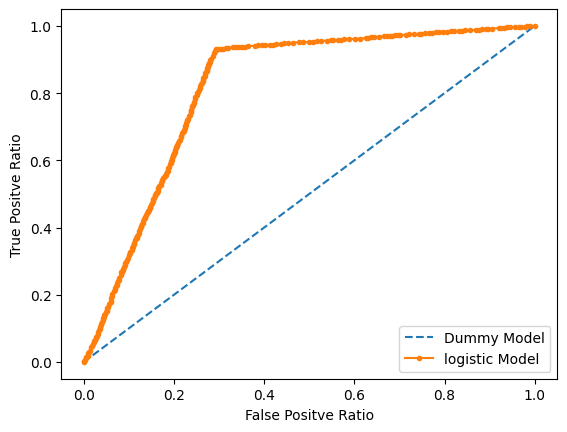

In [58]:
from matplotlib import pyplot
pyplot.plot(dummy_fpr , dummy_tpr , linestyle = '--' , label = 'Dummy Model')
pyplot.plot(model_fpr , model_tpr , marker = '.' , label = 'logistic Model')

pyplot.xlabel("False Positve Ratio")
pyplot.ylabel("True Positve Ratio")

pyplot.legend()

pyplot.show()

# Storing Dataset

In [59]:
df.to_csv('Cleaned_Encoded_Dataset')

# New Test Data

In [69]:
grid.predict([
    [
    0,        # Gender
    29,       # Age
    2,        # Dependents
    0,        # Education
    25000,    # Annual_Income
    3000,     # Monthly_Expenses
    580,      # Credit_Score
    2,        # Existing_Loans
    40000,    # Total_Existing_Loan_Amount
    45000,    # Outstanding_Debt
    0,        # Loan_History
    200000,   # Loan_Amount_Requested
    120,      # Loan_Term
    13.5,     # Interest_Rate
    0,        # Loan_Type
    1,        # Co-Applicant
    0,        # Bank_Account_History
    10,       # Transaction_Frequency
    1,        # Default_Risk
    0,        # Marital_Status_Married
    1,        # Marital_Status_Single
    0,        # Employment_Status_Self-Employed
    1,        # Employment_Status_Unemployed
    1,        # Occupation_Type_Freelancer
    0,        # Occupation_Type_Professional
    0,        # Occupation_Type_Salaried
    0,        # Residential_Status_Own
    1,        # Residential_Status_Rent
    1,        # City/Town_Suburban
    0,        # City/Town_Urban
    0,        # Loan_Purpose_Home
    1,        # Loan_Purpose_Personal
    0,        # Loan_Purpose_Vehicle
    24000000, # Loan_X_Term
    0.85,     # Debt_to_income_ratio
    2083,     # Monthly_Income
    0.75      # loan_income_ratio
  ]
])


array([0])

In [70]:
grid.predict([
  [
    1,        # Gender
    35,       # Age
    1,        # Dependents
    1,        # Education
    90000,    # Annual_Income
    2500,     # Monthly_Expenses
    720,      # Credit_Score
    1,        # Existing_Loans
    20000,    # Total_Existing_Loan_Amount
    15000,    # Outstanding_Debt
    1,        # Loan_History
    150000,   # Loan_Amount_Requested
    240,      # Loan_Term
    8.5,      # Interest_Rate
    1,        # Loan_Type
    0,        # Co-Applicant
    1,        # Bank_Account_History
    35,       # Transaction_Frequency
    0,        # Default_Risk
    1,        # Marital_Status_Married
    0,        # Marital_Status_Single
    0,        # Employment_Status_Self-Employed
    0,        # Employment_Status_Unemployed
    0,        # Occupation_Type_Freelancer
    0,        # Occupation_Type_Professional
    1,        # Occupation_Type_Salaried
    1,        # Residential_Status_Own
    0,        # Residential_Status_Rent
    0,        # City/Town_Suburban
    1,        # City/Town_Urban
    1,        # Loan_Purpose_Home
    0,        # Loan_Purpose_Personal
    0,        # Loan_Purpose_Vehicle
    36000000, # Loan_X_Term
    0.18,     # Debt_to_income_ratio
    7500,     # Monthly_Income
    0.22      # loan_income_ratio
  ]
]
)

array([1])

-------------------------------------------------------------------------------------------------------------------------------------------------

# Observation
- We did the prediction on the loan_approval dataset using decision tree algortihm , by doing hyper parameter tuning we got accuracy of 85% 